# Phase 1: Loading with the Right Delimiter

In [ ]:
import os

In [ ]:
os.listdir('../')

['Real-time Meteor Parameter Prediction and Classification',
 'traj_summary_all.txt']

In [1]:
import pandas as pd
import numpy as np

# Define the path to your large text file
file_path = 'traj_summary_all.txt'

In [2]:
# Manually create the list of column names from the header
# I've taken these from the header you provided. We might need to clean them up.
col_names = [
    'identifier', 'julian_date', 'utc_time', 'iau_no', 'iau_code', 'sol_lon',
    'app_lst', 'rageo', 'rageo_err', 'decgeo', 'decgeo_err', 'lamgeo', 'lamgeo_err',
    'betgeo', 'betgeo_err', 'vgeo', 'vgeo_err', 'lamhel', 'lamhel_err', 'bethel',
    'bethel_err', 'vhel', 'vhel_err', 'a', 'a_err', 'e', 'e_err', 'i', 'i_err',
    'peri', 'peri_err', 'node', 'node_err', 'pi', 'pi_err', 'b', 'b_err', 'q',
    'q_err', 'f', 'f_err', 'm', 'm_err', 'Q', 'Q_err', 'n', 'n_err', 'T', 'T_err',
    'tisserandJ', 'tisserandJ_err', 'raapp', 'raapp_err', 'decapp', 'decapp_err',
    'azim', 'azim_err', 'elev', 'elev_err', 'vinit', 'vinit_err', 'vavg', 'vavg_err',
    'lat_beg', 'lat_beg_err', 'lon_beg', 'lon_beg_err', 'ht_beg', 'ht_beg_err',
    'lat_end', 'lat_end_err', 'lon_end', 'lon_end_err', 'ht_end', 'ht_end_err',
    'duration', 'peak_abs_mag', 'peak_ht', 'F_param', 'mass_kg', 'Qc', 'median_fit_err',
    'beg_in_fov', 'end_in_fov', 'num_stat', 'participating_stations'
]

# The data starts after the '----' line. Let's count the header lines.
# Summary line, blank line, header, units, '---' line. That's 5 lines to skip.
# Let's try loading a small chunk first to test.
try:
    # --- THIS IS THE CORRECTED CODE ---
    # Use read_csv, the workhorse for delimited files.
    df = pd.read_csv(
        file_path,
        delimiter=';',          # The separator is a semicolon
        comment='#',            # Lines starting with '#' are comments
        header=None,            # No header row in the data itself
        names=col_names,        # Use our defined column names
        skipinitialspace=True,  # Handles whitespace after the delimiter
        low_memory=False,       # Better for mixed data types in large files
    )
    # --- END OF CORRECTION ---

    print("Successfully loaded the data using the correct parser!")
    print("DataFrame Info:")
    df.info()
    print("\nFirst 5 rows:")
    print(df.head())

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please check the file_path. The parser settings should now be correct.")

Successfully loaded the data using the correct parser!
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180732 entries, 0 to 180731
Data columns (total 86 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   identifier              180732 non-null  object 
 1   julian_date             180732 non-null  float64
 2   utc_time                180732 non-null  object 
 3   iau_no                  180732 non-null  float64
 4   iau_code                180732 non-null  object 
 5   sol_lon                 180732 non-null  float64
 6   app_lst                 180732 non-null  float64
 7   rageo                   180732 non-null  float64
 8   rageo_err               180557 non-null  float64
 9   decgeo                  180732 non-null  float64
 10  decgeo_err              180557 non-null  float64
 11  lamgeo                  180732 non-null  float64
 12  lamgeo_err              180557 non-null  float64
 13  bet

# Phase 2: Data Cleaning and Preparation

In [3]:
df

,identifier,julian_date,utc_time,iau_no,iau_code,sol_lon,app_lst,rageo,rageo_err,decgeo,...,peak_abs_mag,peak_ht,F_param,mass_kg,Qc,median_fit_err,beg_in_fov,end_in_fov,num_stat,participating_stations
0,3:26:03.824938,-1.000000e+00,...,183.607617,324.698774,21.425570,0.665300,4.82506,1.3472,21.60861,...,0.83,0.000026,34.410,72.990000,True,True,2,"AU000C,AU001S",NaN,NaN
1,20240926132903_jDcqV,2.460580e+06,2024-09-26 13:29:03.571821,-1.000000,...,183.609657,16.689412,104.76045,0.6998,-56.63008,...,0.85,93.270200,0.255,0.000097,16.11,49.22,True,True,3.0,"NZ000V,NZ0020,NZ002E"
2,20240926133058_bHqra,2.460580e+06,2024-09-26 13:30:58.698374,-1.000000,...,183.610964,19.463815,73.39575,0.3755,1.16632,...,0.97,106.652700,0.577,0.000006,89.25,60.37,True,True,2.0,"NZ000S,NZ001C"
3,20240926133245_Pl2GN,2.460580e+06,2024-09-26 13:32:45.478201,-1.000000,...,183.612176,336.228903,46.72234,1.2492,76.83408,...,-1.31,100.272200,0.607,0.000137,33.62,45.03,True,True,2.0,"KR0037,KR003N"
4,20240926133743_oXtkC,2.460580e+06,2024-09-26 13:37:43.514163,-1.000000,...,183.615559,325.805108,338.33493,0.9695,-67.63470,...,1.03,77.345200,0.210,0.000223,51.29,51.52,True,True,5.0,"AU000F,AU000G,AU001A,AU001Y,AU003H"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180727,20241206051845_6QSV3,2.460651e+06,2024-12-06 05:18:45.094213,-1.000000,...,254.236018,155.015742,328.62671,0.6445,65.97963,...,2.39,82.539600,0.512,0.000032,29.73,72.85,True,True,3.0,"UK008F,UK00AN,UK00AT"
180728,20241206051854_Acp8Q,2.460651e+06,2024-12-06 05:18:54.962757,-1.000000,...,254.236133,157.016141,198.84672,0.1363,32.20043,...,-0.22,91.192300,0.947,0.000015,88.71,88.08,True,True,8.0,"BE000B,UK0004,UK0034,UK003W,UK004C,UK006B,UK00..."
180729,20241206051908_BpXcf,2.460651e+06,2024-12-06 05:19:08.386221,-1.000000,...,254.236291,149.324574,100.40318,0.3209,29.78956,...,-1.11,86.864100,0.667,0.000174,82.62,62.74,True,True,7.0,"UK001M,UK0024,UK00A1,UK00AU,UK00BB,UK00BL,UK00C6"
180730,20241206051910_ojxwH,2.460651e+06,2024-12-06 05:19:10.547987,-1.000000,...,254.236315,44.166755,103.98431,0.5045,32.24193,...,1.78,96.340500,0.296,0.000014,22.22,41.48,True,True,2.0,"USL007,USL00D"


In [4]:
feature_cols = ['sol_lon', 'rageo', 'decgeo', 'vgeo', 'azim', 'elev']
target_col = 'iau_code'
all_cols = feature_cols + [target_col]

print(f"Selected Features (X): {feature_cols}")
print(f"Selected Target (y): {target_col}\n")

Selected Features (X): ['sol_lon', 'rageo', 'decgeo', 'vgeo', 'azim', 'elev']
Selected Target (y): iau_code



In [5]:
df_clean = df[all_cols].copy()

In [6]:
df_clean[target_col] = df_clean[target_col].str.strip()
df_clean.loc[df_clean[target_col] == '...', target_col] = 'Sporadic'

In [7]:
for col in feature_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [8]:
print("--- Data Cleaning Report ---")
print("Missing values BEFORE dropping rows:")
df_clean.isnull().sum()

--- Data Cleaning Report ---
Missing values BEFORE dropping rows:


,0
sol_lon,0
rageo,0
decgeo,0
vgeo,0
azim,1
elev,1
iau_code,0


In [9]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180732 entries, 0 to 180731
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   sol_lon   180732 non-null  float64
 1   rageo     180732 non-null  float64
 2   decgeo    180732 non-null  float64
 3   vgeo      180732 non-null  float64
 4   azim      180731 non-null  float64
 5   elev      180731 non-null  float64
 6   iau_code  180732 non-null  object 
dtypes: float64(6), object(1)
memory usage: 9.7+ MB


In [10]:
df_clean[feature_cols].shape

(180732, 6)

In [11]:
print("\nStatistical summary of our features (X):")
df_clean[feature_cols].describe()


Statistical summary of our features (X):


,sol_lon,rageo,decgeo,vgeo,azim,elev
count,180732.000000,180732.000000,180732.000000,180732.000000,180731.000000,180731.000000
mean,219.981546,115.477212,16.750293,43.637671,145.565487,46.473688
std,21.055426,79.102600,31.281363,19.629302,93.012390,17.126142
min,21.425570,0.003130,-89.114400,1.295480,0.003380,-28.899050
25%,201.598010,59.922425,3.621097,26.699520,75.812690,33.868275
50%,218.059405,98.768450,16.180805,42.654680,127.100730,46.527470
75%,239.990672,142.636915,34.479720,63.620910,201.779435,59.059625
max,254.236378,359.998850,89.823490,324.927650,359.998150,89.812190


In [12]:
print("\nDistribution of our target variable (y):")
df_clean[target_col].value_counts()


Distribution of our target variable (y):


,count
iau_code,
Sporadic,129276
ORI,10664
STA,4564
HYD,2474
LEO,2281
...,...
ARD,2
CCR,2
EAN,2


# Phase 3: Exploratory Data Analysis (EDA) & Visualizing the Physics

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
top_classes = df_clean[target_col].value_counts().nlargest(11).index
df_plot = df_clean[df_clean[target_col].isin(top_classes)].copy()

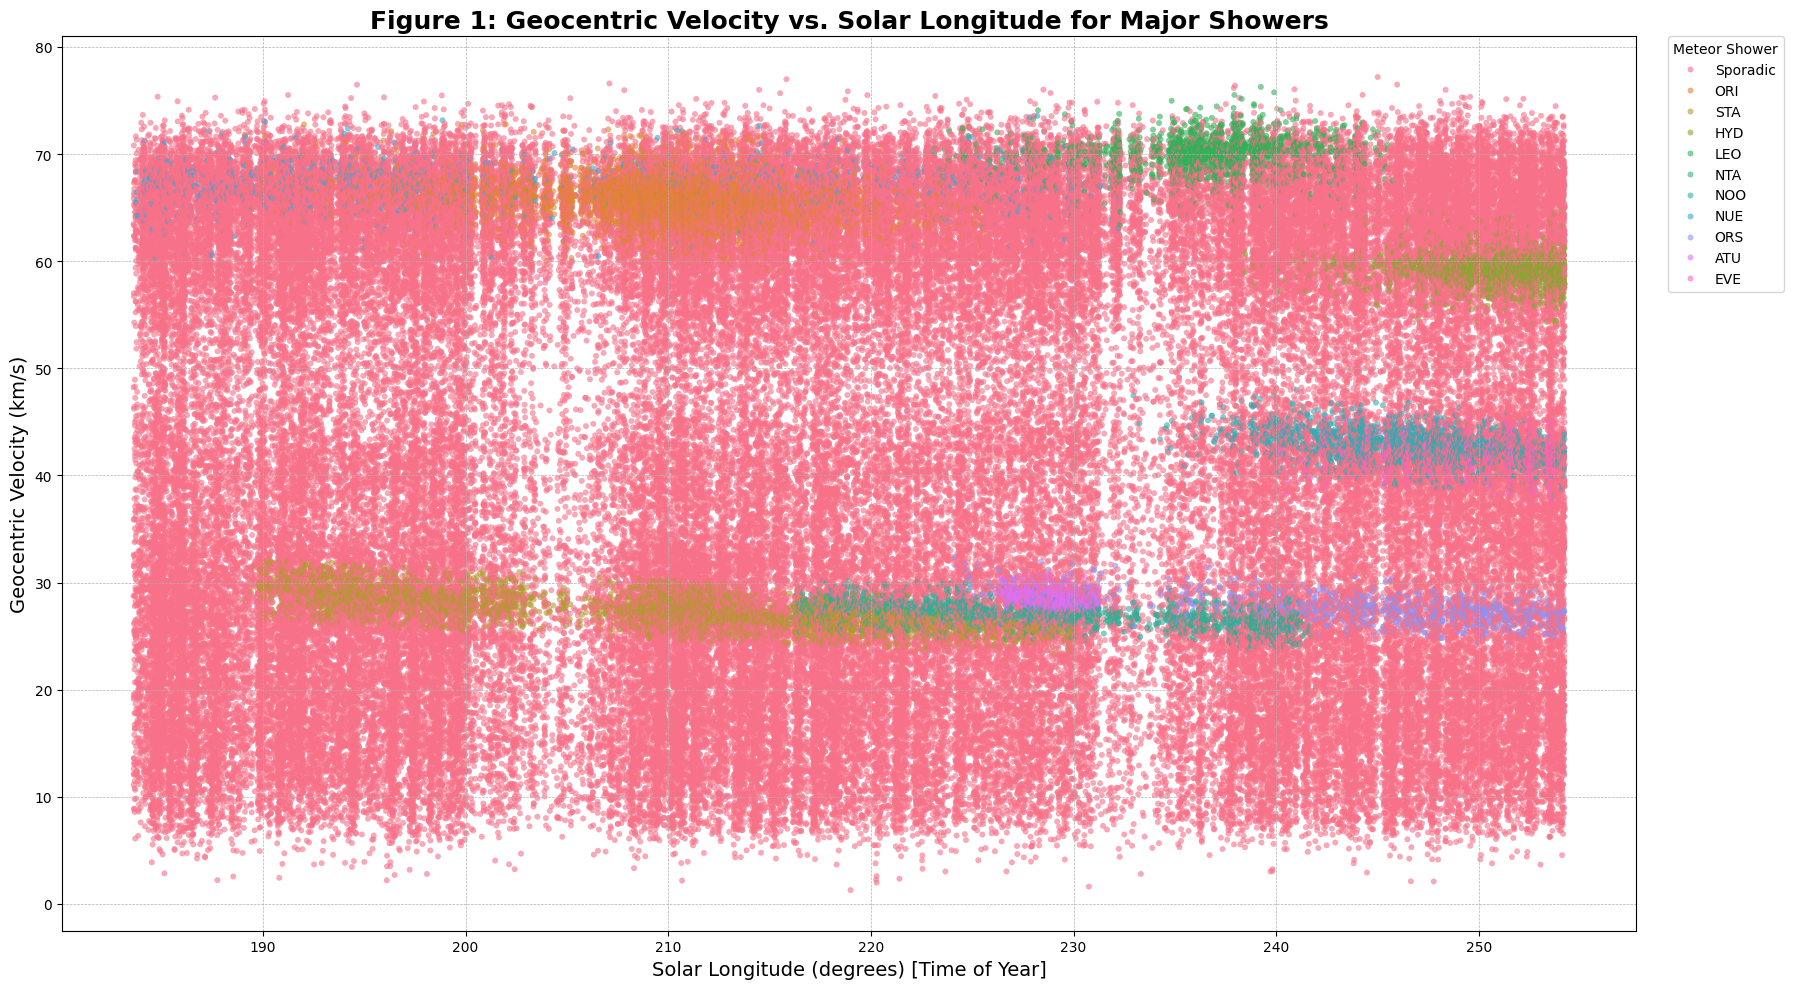

In [15]:
# --- PLOT 1: Velocity vs. Time of Year ---
# This plot will show that showers are groups of meteors with similar velocities
# that occur at specific times of the year.

# For clarity, let's plot only the top N showers + 'Sporadic'
# We take the top 11 to include 'Sporadic' which is the most frequent.
plt.figure(figsize=(18, 10))
sns.scatterplot(
    data=df_plot,
    x='sol_lon',
    y='vgeo',
    hue=target_col,    # Color points by their shower
    s=15,              # Smaller marker size
    alpha=0.6,
    edgecolor=None,
    hue_order=top_classes # Keep a consistent color order
)
plt.title('Figure 1: Geocentric Velocity vs. Solar Longitude for Major Showers', fontsize=18, weight='bold')
plt.xlabel('Solar Longitude (degrees) [Time of Year]', fontsize=14)
plt.ylabel('Geocentric Velocity (km/s)', fontsize=14)
plt.legend(title='Meteor Shower', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

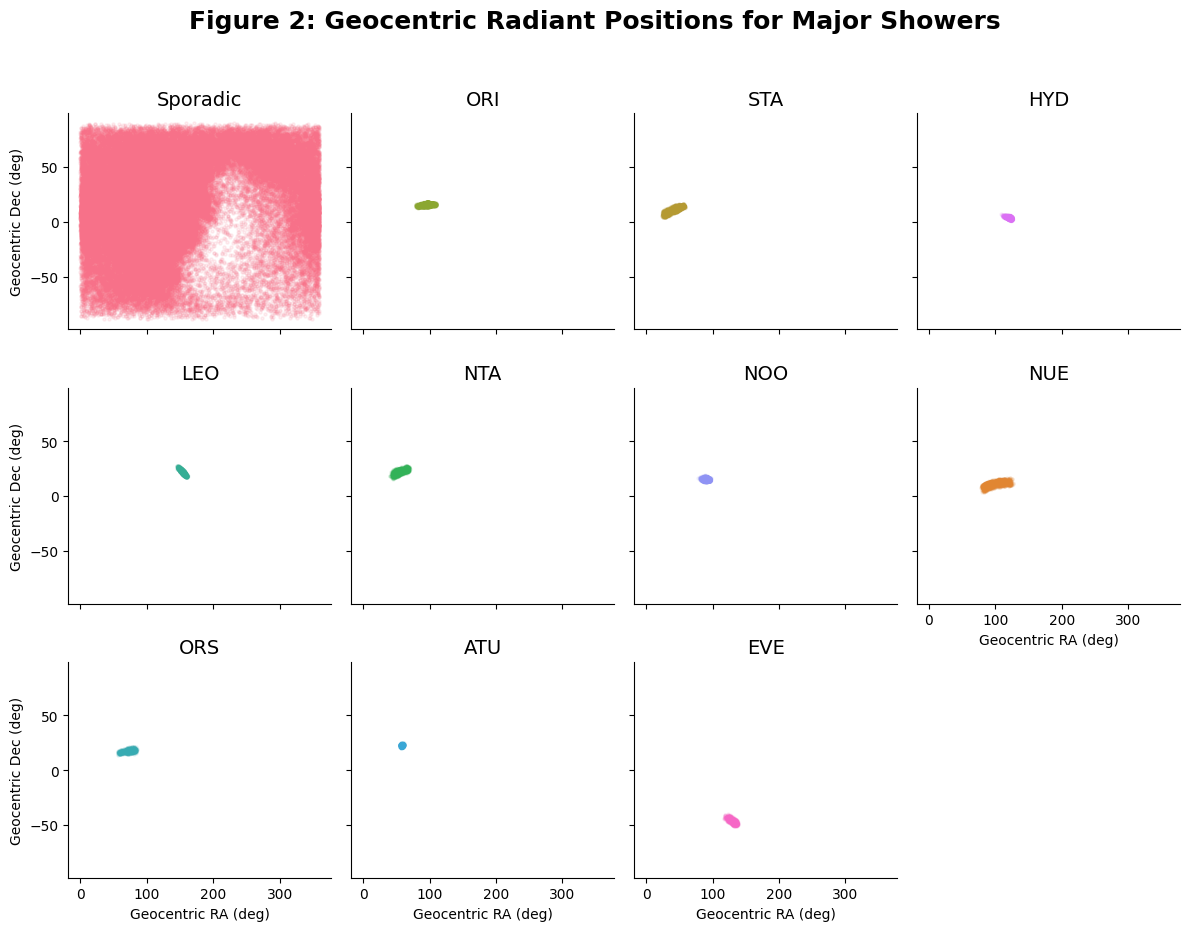

In [16]:
# --- PLOT 2: Radiant Map on the Sky ---
# This plot shows that meteors from a given shower appear to originate
# from the same point (the radiant) on the celestial sphere.

# We need to handle the 0/360 degree wrap-around for Right Ascension (RA)
# The Aitoff projection handles this well.
df_plot['rageo_rad_centered'] = np.deg2rad(df_plot['rageo'] - 180) # Center RA at 180 degrees
df_plot['decgeo_rad'] = np.deg2rad(df_plot['decgeo'])

# We will create a facet grid, one subplot for each shower, to see the clusters clearly.
g = sns.FacetGrid(df_plot, col=target_col, col_wrap=4, hue=target_col, col_order=top_classes)
g.map(plt.scatter, "rageo", "decgeo", s=5, alpha=0.1)
g.set_titles("{col_name}", size=14)
g.set_axis_labels("Geocentric RA (deg)", "Geocentric Dec (deg)")
g.fig.suptitle('Figure 2: Geocentric Radiant Positions for Major Showers', y=1.03, fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

# Phase 4: Modeling - Building the Classifier


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# import xgboost as xgb

In [18]:
# --- 1. PREPARE DATA FOR MODELING ---

# Let's use the df_clean from our preprocessing step.
# For simplicity and speed, let's work with the top 10 showers + 'Sporadic'
# This is the same set of classes we visualized.
top_classes = df_clean[target_col].value_counts().nlargest(11).index
model_df = df_clean[df_clean[target_col].isin(top_classes)].copy()

print(f"--- Modeling with {len(top_classes)} classes ---")
print(model_df[target_col].value_counts())

--- Modeling with 11 classes ---
iau_code
Sporadic    129276
ORI          10664
STA           4564
HYD           2474
LEO           2281
NTA           2161
NOO           2068
NUE           1228
ORS           1036
ATU            969
EVE            961
Name: count, dtype: int64


In [19]:
# Define Features (X) and Target (y)
X = model_df[feature_cols]
y_str = model_df[target_col]

# Encode the string labels (y) into integers (e.g., Sporadic -> 0, PER -> 1, ...)
le = LabelEncoder()
y = le.fit_transform(y_str)

In [20]:
# Split data into training and testing sets (80% train, 20% test)
# 'stratify=y' is CRITICAL for imbalanced datasets. It ensures the class
# distribution is the same in both the train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
# Scale the features. This helps most models converge faster and perform better.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")


Training set shape: (126145, 6)
Testing set shape: (31537, 6)


## XGBoost

In [ ]:
# --- 2. TRAIN THE XGBoost MODEL ---

print("\n--- Training XGBoost Classifier ---")
# Initialize the XGBoost classifier
# We use 'multi:softmax' for multi-class classification
# 'n_estimators' is the number of trees; 'max_depth' controls their complexity.
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(top_classes),
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1, # Use all available CPU cores
    random_state=42
)
# Train the model
xgb_clf.fit(X_train_scaled, y_train)
print("Model training complete.")


--- Training XGBoost Classifier ---


In [ ]:
# --- 3. EVALUATE THE MODEL ---
print("\n--- Model Evaluation on Test Set ---")
y_pred = xgb_clf.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

# Print detailed classification report (Precision, Recall, F1-score)
# We need to use the original string labels for readability
class_names = le.classes_
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


--- Model Evaluation on Test Set ---
Overall Accuracy: 0.9836

Classification Report:
              precision    recall  f1-score   support

         CAP       0.87      0.97      0.92      1596
         ETA       0.92      0.98      0.95      2991
         GEM       0.96      1.00      0.98     13489
         HYD       0.88      0.98      0.92      2149
         LEO       0.87      0.94      0.90      1620
         ORI       0.90      0.98      0.94      7952
         PER       0.92      0.98      0.95     18324
         QUA       0.98      1.00      0.99      2440
         SDA       0.92      0.98      0.95      4030
         STA       0.83      0.96      0.89      2771
    Sporadic       1.00      0.98      0.99    299079

    accuracy                           0.98    356441
   macro avg       0.91      0.98      0.94    356441
weighted avg       0.98      0.98      0.98    356441



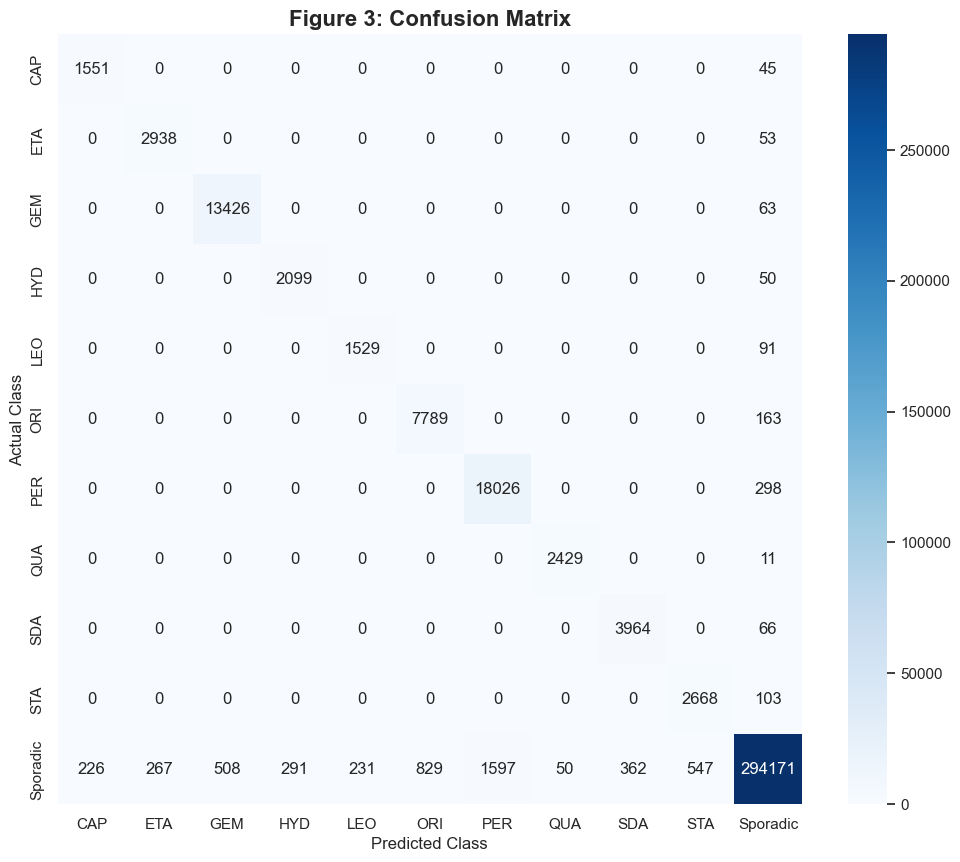

In [ ]:
# --- 4. VISUALIZE RESULTS ---

# Plot 1: Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Figure 3: Confusion Matrix', fontsize=16, weight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

<Figure size 1000x600 with 0 Axes>

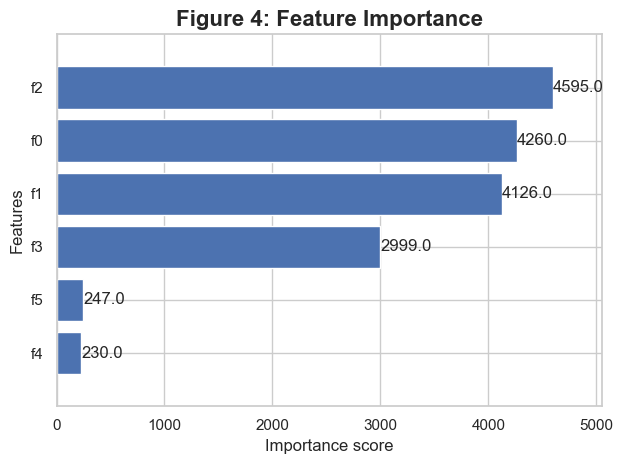

In [ ]:
# Plot 2: Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_clf, importance_type='weight', max_num_features=10, height=0.8)
plt.title('Figure 4: Feature Importance', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# make a comparison

In [22]:
import time
import pandas as pd
from sklearn.linear_model import LogisticRegression
# import lightgbm as lgb
models = {}
results = {}

In [ ]:
# --- Model 1: Logistic Regression (Simple Baseline) ---
print("--- Training Logistic Regression ---")
start_time = time.time()
log_reg = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train_scaled, y_train)
end_time = time.time()

y_pred_log_reg = log_reg.predict(X_test_scaled)
models['Logistic Regression'] = log_reg
results['Logistic Regression'] = {
    "accuracy": accuracy_score(y_test, y_pred_log_reg),
    "report": classification_report(y_test, y_pred_log_reg, target_names=class_names, output_dict=True),
    "training_time": end_time - start_time
}
print(f"Logistic Regression Training Time: {results['Logistic Regression']['training_time']:.2f} seconds")
print(f"Logistic Regression Accuracy: {results['Logistic Regression']['accuracy']:.4f}\n")

--- Training Logistic Regression ---
Logistic Regression Training Time: 136.24 seconds
Logistic Regression Accuracy: 0.8697



c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [ ]:
# --- Model 2: LightGBM (Fast Contender) ---
print("--- Training LightGBM ---")
start_time = time.time()
lgb_clf = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
lgb_clf.fit(X_train_scaled, y_train)
end_time = time.time()

y_pred_lgb = lgb_clf.predict(X_test_scaled)
models['LightGBM'] = lgb_clf
results['LightGBM'] = {
    "accuracy": accuracy_score(y_test, y_pred_lgb),
    "report": classification_report(y_test, y_pred_lgb, target_names=class_names, output_dict=True),
    "training_time": end_time - start_time
}
print(f"LightGBM Training Time: {results['LightGBM']['training_time']:.2f} seconds")
print(f"LightGBM Accuracy: {results['LightGBM']['accuracy']:.4f}\n")

--- Training LightGBM ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 1425763, number of used features: 6
[LightGBM] [Info] Start training from score -5.408511
[LightGBM] [Info] Start training from score -4.780560
[LightGBM] [Info] Start training from score -3.274331
[LightGBM] [Info] Start training from score -5.110816
[LightGBM] [Info] Start training from score -5.393896
[LightGBM] [Info] Start training from score -3.802776
[LightGBM] [Info] Start training from score -2.967984
[LightGBM] [Info] Start training from score -4.983965
[LightGBM] [Info] Start training from score -4.482464
[LightGBM] [Info] Start training from score -4.857050
[LightGBM] [Info] Start training from score -0.175459


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Training Time: 22.24 seconds
LightGBM Accuracy: 0.9836



In [ ]:
# --- Model 3: XGBoost (Our Champion Baseline) ---
# We'll re-run it to get a consistent timing measurement.
print("--- Training XGBoost ---")
start_time = time.time()
# Use the same parameters as before
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax', num_class=len(class_names), n_estimators=100,
    max_depth=5, learning_rate=0.1, use_label_encoder=False,
    eval_metric='mlogloss', n_jobs=-1, random_state=42
)
xgb_clf.fit(X_train_scaled, y_train)
end_time = time.time()

y_pred_xgb = xgb_clf.predict(X_test_scaled)
models['XGBoost'] = xgb_clf
results['XGBoost'] = {
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "report": classification_report(y_test, y_pred_xgb, target_names=class_names, output_dict=True),
    "training_time": end_time - start_time
}
print(f"XGBoost Training Time: {results['XGBoost']['training_time']:.2f} seconds")
print(f"XGBoost Accuracy: {results['XGBoost']['accuracy']:.4f}\n")

--- Training XGBoost ---


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [06:10:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Training Time: 40.44 seconds
XGBoost Accuracy: 0.9836



In [ ]:
# --- Summarize Results ---
results_df = pd.DataFrame(columns=['Model', 'Training Time (s)', 'Accuracy', 'F1-Score (weighted)'])
for name, res in results.items():
    results_df.loc[len(results_df)] = [
        name,
        round(res['training_time'], 2),
        round(res['accuracy'], 4),
        round(res['report']['weighted avg']['f1-score'], 4)
    ]

print("--- Comparative Results ---")
print(results_df.sort_values(by='Accuracy', ascending=False))

--- Comparative Results ---
                 Model  Training Time (s)  Accuracy  F1-Score (weighted)
1             LightGBM              22.24    0.9836               0.9836
2              XGBoost              40.44    0.9836               0.9839
0  Logistic Regression             136.24    0.8697               0.8277


# TabTransformer

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim


In [54]:
class TabTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, num_layers=2, d_model=64, nhead=4):
        super(TabTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
      x = self.embedding(x)
      x = x.unsqueeze(1)
      x = self.transformer(x)
      # Fix: Correctly apply mean over dimension 1
      x = x.mean(dim=1)  # Global average pooling
      x = self.fc(x)
      return x


In [55]:
num_features = X_train_scaled.shape[1]
num_classes = 11

In [56]:
model = TabTransformer(input_dim=num_features, num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [57]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [58]:
from tqdm import tqdm

In [59]:
start_time = time.time()
for epoch in tqdm(range(1000)):  # Training for 100 epochs
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

end_time = time.time()
print(f"Training complete in {end_time - start_time:.2f} seconds.")

  1%|          | 10/1000 [03:36<5:56:16, 21.59s/it]

Epoch [10/100], Loss: 0.7840


  2%|▏         | 20/1000 [07:15<5:55:10, 21.75s/it]

Epoch [20/100], Loss: 0.7178


  3%|▎         | 30/1000 [10:52<5:50:42, 21.69s/it]

...

Epoch [330/100], Loss: 0.0742


 34%|███▍      | 340/1000 [2:02:21<3:56:38, 21.51s/it]

Epoch [340/100], Loss: 0.0738


 34%|███▍      | 341/1000 [2:02:53<3:57:28, 21.62s/it]


KeyboardInterrupt: 

In [61]:
end_time = time.time()
print(f"Training complete in {end_time - start_time:.2f} seconds.")

Training complete in 7396.93 seconds.


In [60]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred = torch.max(y_pred_tensor, 1)

# Calculate accuracy
accuracy = accuracy_score(y_test_tensor.numpy(), y_pred.numpy())
print(f"TabTransformer Accuracy: {accuracy:.4f}")
class_names = le.classes_
# Print detailed classification report
print("\nClassification Report for TabTransformer:")
print(classification_report(y_test_tensor.numpy(), y_pred.numpy(), target_names=class_names))


TabTransformer Accuracy: 0.9744

Classification Report for TabTransformer:
              precision    recall  f1-score   support

         ATU       0.82      0.99      0.90       194
         EVE       0.59      0.97      0.73       192
         HYD       0.90      0.98      0.94       495
         LEO       0.86      0.99      0.92       456
         NOO       0.86      0.98      0.91       414
         NTA       0.92      0.91      0.91       432
         NUE       0.84      0.94      0.88       245
         ORI       0.93      0.99      0.96      2133
         ORS       0.88      0.95      0.91       207
         STA       0.93      0.98      0.95       913
    Sporadic       1.00      0.97      0.98     25856

    accuracy                           0.97     31537
   macro avg       0.86      0.97      0.91     31537
weighted avg       0.98      0.97      0.98     31537



In [62]:
# Get the classification report as a dictionary
report_dict = classification_report(y_test_tensor.numpy(), y_pred.numpy(), target_names=class_names, output_dict=True)

# Access the weighted average F1-score from the dictionary
weighted_f1_score = report_dict['weighted avg']['f1-score']

# Print the weighted average F1-score
print(f"Weighted Average F1-score: {weighted_f1_score:.4f}")

Weighted Average F1-score: 0.9753


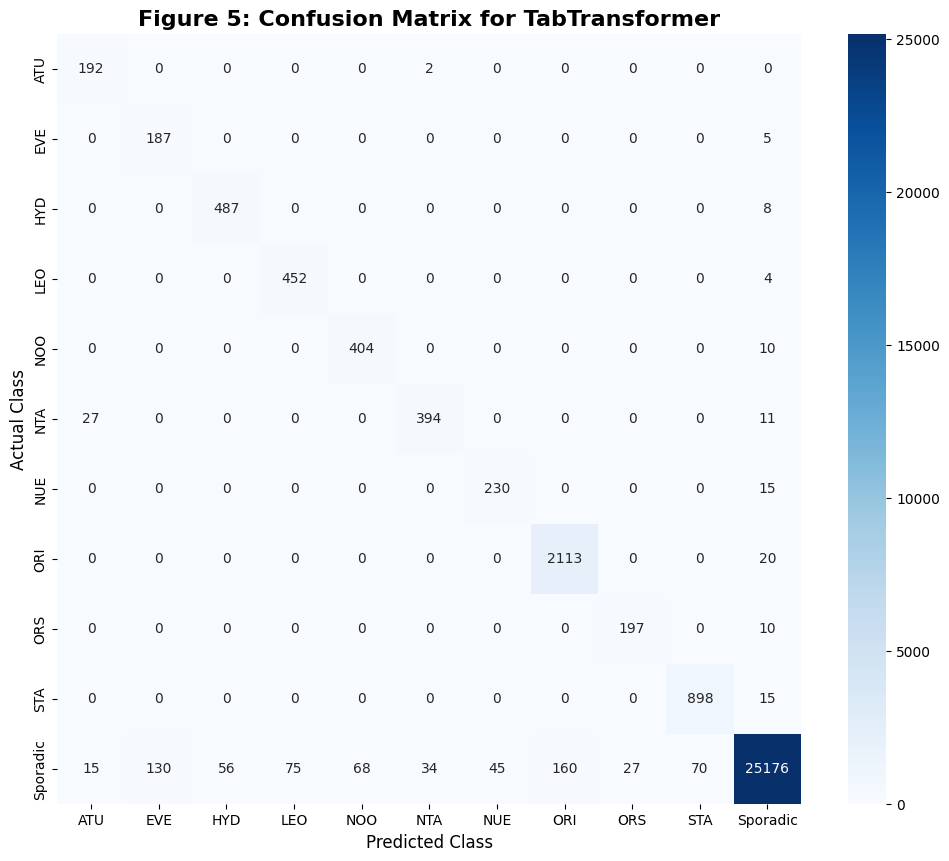

In [63]:
# Plot confusion matrix for TabTransformer
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test_tensor.numpy(), y_pred.numpy())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Figure 5: Confusion Matrix for TabTransformer', fontsize=16, weight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()